In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime
import PMDevice
import keyboard
import TLX_5

In [2]:
# Power meter connection

power_meter = PMDevice.PMDevice()
power_meter.find_devices()
power_meter.connect()

Number of found devices: 1

Resource name of device 0: USB0::0x1313::0x80B4::250214211::INSTR

Device connected
Last calibration date: 14-FEB-2025 



In [9]:
# Wavelength in nm
w = 1550
power_meter.set_wavelength(w)

In [3]:
power_meter.set_autorange(True)

In [5]:
units = "W"

power_meter.set_unit(units)

Units set to Watts


In [6]:
power_meter.newTimeOut(20)

In [10]:
power_meter.SetAvMeasure(2)

In [11]:
p = power_meter.read_power()
print(p)

0.000807587


In [13]:
measure = power_meter.measure_series(count=5, interval=1)

2026-08-03 09:16:19.335526 : 0.000808328 W
2026-08-03 09:16:20.339636 : 0.000808111 W
2026-08-03 09:16:21.343569 : 0.00080792 W
2026-08-03 09:16:22.347638 : 0.000808126 W
2026-08-03 09:16:23.351570 : 0.00080935 W



In [9]:

while True:
    p = power_meter.read_power()
    print(f"Power={p} {units}")
    time.sleep(1.0)
    if keyboard.is_pressed("q"):
        break

Power=2.82582 dBm
Power=2.82391 dBm
Power=2.83555 dBm
Power=2.83479 dBm
Power=2.82749 dBm
Power=2.8261 dBm
Power=2.82095 dBm
Power=2.82263 dBm
Power=2.84026 dBm
Power=2.8398 dBm
Power=2.83723 dBm
Power=2.85117 dBm


KeyboardInterrupt: 

In [53]:
measure_length = np.linspace(0, 60, 61)

size=len(measure_length)


In [55]:


power_meter.newTimeOut(5)

power_meter.SetAvMeasureTime(2)

mes_power = []

time=[]
 


In [56]:
for i in range(size):
    time.append(datetime.now())
    pwr = power_meter.read_power()
    mes_power.append(pwr)

    
    

In [57]:
mean=np.mean(mes_power)/1e-6
std=np.std(mes_power)/1e-6
mes_power=[item/1e-6 for item in mes_power]
print(f"Mean Power={mean:.2f} Standard Deviation ={std:.2f}")



Mean Power=810.04 Standard Deviation =0.85


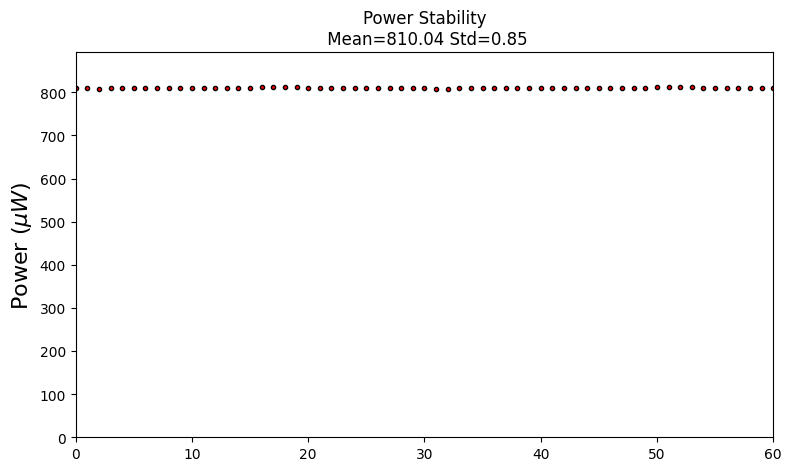

In [58]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    measure_length,mes_power,
    marker='o',         # square markers
    markersize=3,
    markerfacecolor='red',
    markeredgecolor='black',
    linestyle='None'    # disables line
)
    
ax.set_xlim(np.min(measure_length),np.max(measure_length))
ax.set_ylim(0,np.max(mes_power)+0.1*np.max(mes_power))
ax.set_ylabel(r'Power ($\mu W$)', fontsize=16)
plt.title(f"Power Stability\n Mean={mean:.2f} Std={std:.2f}")
plt.show()

In [ ]:
power_meter.disconnect()